# **PHASE 2 — Speech Emotion Recognition (SER)**

In [ ]:
# ==========================================
# CELL 1 — Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ==========================================
# CELL 2 — GPU Configuration
# ==========================================

import torch
import random
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

!nvidia-smi

Device: cuda
GPU Available: True
GPU Name: Tesla T4
CUDA Version: 12.8
Sat Jun  6 17:03:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        | 

In [ ]:
# ==========================================
# CELL 3 — Install Required Libraries
# SER-specific: librosa (audio), requests (RAVDESS download)
# ==========================================

!pip install -q \
    librosa==0.10.1 \
    seaborn \
    requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 22.1 MB/s eta 0:00:00


In [ ]:
# ==========================================
# CELL 4 — Import Libraries (SER)
# ==========================================

# Core
import os
import shutil
import json
import random
import zipfile
import logging
import warnings

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings("ignore")

# HTTP Download
import requests

# Audio
import librosa

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

import time

print("✅ All SER libraries imported successfully.")

✅ All SER libraries imported successfully.


In [ ]:
# ============================================================
# ENVIRONMENT & PATH SETUP (Colab vs Local)
# ============================================================
import os, sys
if os.path.exists("/content/drive"):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    BASE_PATH = "/content/drive/MyDrive/Emotion_Story_Project1"
else:
    # Running locally or inside notebooks/ folder
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    BASE_PATH = PROJECT_ROOT

# Original path definitions below:
# ==========================================
# CELL 5 — Project Configuration (SER)
# ==========================================
# Paths match the shared Drive structure used in FER notebook.
# Running this cell again is safe (exist_ok=True everywhere).

# ---- Emotion Classes (3-class — must match FER) ----
TARGET_CLASSES = ["happy", "neutral", "sad"]
NUM_CLASSES    = len(TARGET_CLASSES)

LABEL_MAP = {"happy": 0, "neutral": 1, "sad": 2}

print("Target Classes  :", TARGET_CLASSES)
print("Number of Classes:", NUM_CLASSES)

# ---- Base Drive Path ----
BASE_PATH = "/content/drive/MyDrive/Emotion_Story_Project1"

os.makedirs(BASE_PATH, exist_ok=True)
assert os.path.exists(BASE_PATH), f"Base path not found: {BASE_PATH}"

# ---- Data Paths ----
DATA_PATH    = os.path.join(BASE_PATH, "data")
FER_PATH     = os.path.join(DATA_PATH, "fer2013")   # created by FER notebook
RAVDESS_PATH = os.path.join(DATA_PATH, "ravdess")

# ---- Model Paths ----
MODEL_PATH        = os.path.join(BASE_PATH, "models")
FACIAL_MODEL_PATH = os.path.join(MODEL_PATH, "facial")   # output of FER notebook
AUDIO_MODEL_PATH  = os.path.join(MODEL_PATH, "audio")
FUSION_MODEL_PATH = os.path.join(MODEL_PATH, "fusion")   # used by Fusion notebook

# ---- Output Paths ----
OUTPUT_PATH        = os.path.join(BASE_PATH, "outputs")
STORY_OUTPUT_PATH  = os.path.join(OUTPUT_PATH, "stories")
AUDIO_OUTPUT_PATH  = os.path.join(OUTPUT_PATH, "audio")
IMAGE_OUTPUT_PATH  = os.path.join(OUTPUT_PATH, "images")
VIDEO_OUTPUT_PATH  = os.path.join(OUTPUT_PATH, "video")
METRIC_OUTPUT_PATH = os.path.join(OUTPUT_PATH, "metrics")

print("\n✅ Project paths configured.")
print(f"   Base  : {BASE_PATH}")
print(f"   Audio : {AUDIO_MODEL_PATH}")

Target Classes  : ['happy', 'neutral', 'sad']
Number of Classes: 3

✅ Project paths configured.
   Base  : /content/drive/MyDrive/Emotion_Story_Project1
   Audio : /content/drive/MyDrive/Emotion_Story_Project1/models/audio


In [ ]:
# ==========================================
# CELL 6 — Create Project Directories
# ==========================================
# Re-creates any missing folders (safe with exist_ok=True).

folders = [
    FER_PATH,
    RAVDESS_PATH,
    FACIAL_MODEL_PATH,
    AUDIO_MODEL_PATH,
    FUSION_MODEL_PATH,
    STORY_OUTPUT_PATH,
    AUDIO_OUTPUT_PATH,
    IMAGE_OUTPUT_PATH,
    VIDEO_OUTPUT_PATH,
    METRIC_OUTPUT_PATH
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

for folder in folders:
    assert os.path.exists(folder), f"Failed to create: {folder}"

print("✅ All project directories created/verified successfully.")

✅ All project directories created/verified successfully.


In [ ]:
# ============================================
# CELL 7 — Audio Setup & Logging
# ============================================

# ---- Audio Project Subfolder ----

AUDIO_MODEL_PATH = os.path.join(BASE_PATH, "models/audio")
os.makedirs(AUDIO_MODEL_PATH, exist_ok=True)

for folder in ["logs", "checkpoints", "plots"]:
    os.makedirs(os.path.join(AUDIO_MODEL_PATH, folder), exist_ok=True)

print("Audio project folders created.")

# ---- Local Runtime Cache (Colab SSD — faster I/O) ----

LOCAL_MEL_CACHE = "/content/mel_cache"
os.makedirs(LOCAL_MEL_CACHE, exist_ok=True)

print("Local mel cache created.")

# ---- Logging ----

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_filename = os.path.join(
    AUDIO_MODEL_PATH, "logs",
    f"training_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
)

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info("Phase 2 Audio Training Started")

print("Logging initialized.")
print("Log file:", log_filename)
print("\nUsing device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Audio project folders created.
Local mel cache created.
Logging initialized.
Log file: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/logs/training_log_20260606_170357.txt

Using device: cuda
GPU Name: Tesla T4


In [ ]:
# ============================================
# CELL 8 — RAVDESS Setup
# Imports & Path Configuration
# ============================================

# ---- Drive ZIP Path (persistent storage) ----

DRIVE_RAVDESS_PATH = os.path.join(
    BASE_PATH, "data", "ravdess.zip"
)

# ---- Local Extraction Root (Colab SSD) ----

EXTRACT_ROOT = "/content"
os.makedirs(EXTRACT_ROOT, exist_ok=True)

print("Drive RAVDESS ZIP path :", DRIVE_RAVDESS_PATH)
print("Local extraction root  :", EXTRACT_ROOT)
print("✅ Paths initialized.")

Drive RAVDESS ZIP path : /content/drive/MyDrive/Emotion_Story_Project1/data/ravdess.zip
Local extraction root  : /content
✅ Paths initialized.


In [ ]:
# ============================================
# CELL 9 — Download RAVDESS
# ============================================
# Downloads Audio_Speech_Actors_01-24.zip from Zenodo.
# Saved to Drive — skipped automatically if already present.
# ~1.2 GB; may take 3–5 minutes on first run.

RAVDESS_URL = (
    "https://zenodo.org/record/1188976/files/"
    "Audio_Speech_Actors_01-24.zip"
)

if not os.path.exists(DRIVE_RAVDESS_PATH):

    print("Downloading RAVDESS (~1.2 GB)...")

    with requests.get(RAVDESS_URL, stream=True) as r:
        r.raise_for_status()
        with open(DRIVE_RAVDESS_PATH, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    print("✅ Download complete. Saved to Drive.")

else:
    print("✅ RAVDESS ZIP already exists on Drive. Skipping download.")

✅ RAVDESS ZIP already exists on Drive. Skipping download.


In [ ]:
# ============================================
# CELL 10 — Extract RAVDESS Dataset Locally
# ============================================
# Extracts to /content (Colab SSD) for fast I/O.
# Skips automatically if Actor folders already exist locally.

actor_check = os.path.join(EXTRACT_ROOT, "Actor_01")

if not os.path.exists(actor_check):
    print("📂 Extracting RAVDESS locally...")
    with zipfile.ZipFile(DRIVE_RAVDESS_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_ROOT)
    print("✅ Extraction complete.")
else:
    print("✅ RAVDESS already extracted locally. Skipping.")

print("📁 Extraction root contents (first 5):",
      os.listdir(EXTRACT_ROOT)[:5])

📂 Extracting RAVDESS locally...
✅ Extraction complete.
📁 Extraction root contents (first 5): ['.config', 'Actor_07', 'Actor_20', 'drive', 'Actor_08']


In [ ]:
# ============================================
# CELL 11 — Detect RAVDESS Dataset Folder
# ============================================
# Walks the extraction root to find the folder
# that contains Actor_01 ... Actor_24 subdirectories.

LOCAL_RAVDESS_PATH = None

for root, dirs, files in os.walk(EXTRACT_ROOT):
    actor_folders = [d for d in dirs if d.startswith("Actor_")]
    if len(actor_folders) > 0:
        LOCAL_RAVDESS_PATH = root
        break

if LOCAL_RAVDESS_PATH is None:
    raise Exception(
        "Could not locate RAVDESS dataset under /content. "
        "Re-run Cell 10 to re-extract."
    )

print("✅ Detected Dataset Path:", LOCAL_RAVDESS_PATH)
print("\nSample folders:", os.listdir(LOCAL_RAVDESS_PATH)[:5])

✅ Detected Dataset Path: /content

Sample folders: ['.config', 'Actor_07', 'Actor_20', 'drive', 'Actor_08']


In [ ]:
# ============================================
# CELL 12 — Parse RAVDESS Dataset
# ============================================
# RAVDESS filename format:
#   modality-vocal_channel-emotion-intensity-statement-repetition-actor.wav
#
# Modality codes:
#   01 = Speech  ← we keep only this
#   02 = Song    ← excluded (different acoustic properties)
#
# Full emotion remapping → 3 project classes:
#   01 = Neutral  → neutral (1)
#   02 = Calm     → neutral (1)  ← both neutral-type emotions merged
#   03 = Happy    → happy   (0)
#   04 = Sad      → sad     (2)
#   05 = Angry    → sad     (2)  ← high-arousal negative → calming story
#   06 = Fear     → sad     (2)  ← distress → calming story
#   07 = Disgust  → sad     (2)  ← negative → calming story
#   08 = Surprise → happy   (0)  ← high-arousal positive → happy story
#
# Output: same 3-class model, ~2.7x more training data.

SPEECH_MODALITY = "03"   # keep speech only, exclude song ("02")

emotion_map = {
    "01": 1,   # neutral  → neutral
    "02": 1,   # calm     → neutral
    "03": 0,   # happy    → happy
    "04": 2,   # sad      → sad
    "05": 2,   # angry    → sad
    "06": 2,   # fear     → sad
    "07": 2,   # disgust  → sad
    "08": 0,   # surprise → happy
}

data = []
skipped_song   = 0
skipped_other  = 0

for actor in sorted(os.listdir(LOCAL_RAVDESS_PATH)):
    actor_path = os.path.join(LOCAL_RAVDESS_PATH, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in sorted(os.listdir(actor_path)):
        if not file.endswith(".wav"):
            continue

        parts = file.split("-")

        # Guard: skip malformed filenames
        if len(parts) < 7:
            skipped_other += 1
            continue

        modality_code = parts[0]
        emotion_code  = parts[2]

        # Keep speech only
        if modality_code != SPEECH_MODALITY:
            skipped_song += 1
            continue

        if emotion_code in emotion_map:
            filepath = os.path.join(actor_path, file)
            label    = emotion_map[emotion_code]
            data.append([filepath, label])
        else:
            skipped_other += 1

df = pd.DataFrame(data, columns=["path", "label"])

# ---- Summary ----

label_names = {0: "happy", 1: "neutral", 2: "sad"}

print("==========================================")
print("RAVDESS Dataset — Full Emotion Remap")
print("==========================================")
print(f"Total samples loaded : {len(df)}")
print(f"Skipped (song files) : {skipped_song}")
print(f"Skipped (other)      : {skipped_other}")
print("\nClass Distribution:")
for lbl, name in label_names.items():
    count = (df["label"] == lbl).sum()
    pct   = count / len(df) * 100
    print(f"  {name:<10}: {count:>4}  ({pct:.1f}%)")

RAVDESS Dataset — Full Emotion Remap
Total samples loaded : 1440
Skipped (song files) : 0
Skipped (other)      : 0

Class Distribution:
  happy     :  384  (26.7%)
  neutral   :  288  (20.0%)
  sad       :  768  (53.3%)


In [ ]:
# ============================================
# CELL 13 — Train / Validation Split
# ============================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Shuffle after split
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
val_df   = val_df.sample(frac=1,   random_state=42).reset_index(drop=True)

print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")

Train size      : 1152
Validation size : 288


In [ ]:
# ============================================
# CELL 14 — Save Metadata CSVs
# ============================================
# Persists split file paths to Drive so the dataset
# can be re-loaded without re-parsing.

train_csv = os.path.join(AUDIO_MODEL_PATH, "train_metadata.csv")
val_csv   = os.path.join(AUDIO_MODEL_PATH, "val_metadata.csv")

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv,   index=False)

print(f"✅ Train metadata saved : {train_csv}")
print(f"✅ Val   metadata saved : {val_csv}")

logging.info(f"Total samples : {len(df)}")
logging.info(f"Train samples : {len(train_df)}")
logging.info(f"Val   samples : {len(val_df)}")

✅ Train metadata saved : /content/drive/MyDrive/Emotion_Story_Project1/models/audio/train_metadata.csv
✅ Val   metadata saved : /content/drive/MyDrive/Emotion_Story_Project1/models/audio/val_metadata.csv


In [ ]:
# ============================================
# CELL 15 — Feature Extraction + AudioDataset
# Fast Cached Pipeline + Stable SpecAugment
# ============================================

# ---- Global Audio Parameters ----

SR           = 22050
N_MELS       = 128
FIXED_LENGTH = 3          # seconds
SAMPLES      = SR * FIXED_LENGTH
BATCH_SIZE   = 32
CACHE_PATH   = LOCAL_MEL_CACHE

os.makedirs(CACHE_PATH, exist_ok=True)

# ---- SpecAugment ----

def spec_augment(features, time_mask=12, freq_mask=8):
    features = features.copy()
    _, f, t = features.shape

    if t > time_mask:
        t0 = np.random.randint(0, t - time_mask)
        features[:, :, t0:t0 + time_mask] = 0

    if f > freq_mask:
        f0 = np.random.randint(0, f - freq_mask)
        features[:, f0:f0 + freq_mask, :] = 0

    return features

# ---- Feature Extraction (Log Mel + Delta + Delta2) ----

def generate_features(filepath):

    y, sr = librosa.load(filepath, sr=SR)
    y, _  = librosa.effects.trim(y, top_db=20)
    y     = librosa.util.normalize(y)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]

    mel    = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=2048, hop_length=512, win_length=2048, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    delta  = librosa.feature.delta(mel_db)
    delta2 = librosa.feature.delta(mel_db, order=2)

    stacked = np.stack([mel_db, delta, delta2], axis=0)

    # Channel-wise normalisation
    for i in range(3):
        stacked[i] = (stacked[i] - stacked[i].mean()) / (stacked[i].std() + 1e-6)

    return stacked

# ---- Dataset ----

class AudioEmotionDataset(Dataset):

    def __init__(self, csv_file, augment=False):
        self.data          = pd.read_csv(csv_file)
        self.augment       = augment
        self.current_epoch = 0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filepath = self.data.iloc[idx]["path"]
        label    = self.data.iloc[idx]["label"]

        # Build stable cache filename
        cache_name = filepath.replace("/", "_").replace(".wav", ".npy")
        cache_file = os.path.join(CACHE_PATH, cache_name)

        if os.path.exists(cache_file):
            features = np.load(cache_file)
            if len(features.shape) != 3:          # safety check
                features = generate_features(filepath)
                np.save(cache_file, features)
        else:
            features = generate_features(filepath)
            np.save(cache_file, features)

        # Adaptive SpecAugment (early epochs only)
        if self.augment and self.current_epoch < 15:
            if np.random.rand() < 0.45:
                features = spec_augment(features)

        return torch.tensor(features).float(), torch.tensor(label).long()

# ---- Create Datasets & DataLoaders ----

train_dataset = AudioEmotionDataset(train_csv, augment=True)
val_dataset   = AudioEmotionDataset(val_csv,   augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# ---- Sanity Check ----

x, y = next(iter(train_loader))

print("✅ Hybrid optimized dataset pipeline ready.")
print(f"Input shape : {x.shape}")
print(f"Label shape : {y.shape}")
print(f"Min  : {x.min().item():.4f}")
print(f"Max  : {x.max().item():.4f}")
print(f"Mean : {x.mean().item():.4f}")

✅ Hybrid optimized dataset pipeline ready.
Input shape : torch.Size([32, 3, 128, 130])
Label shape : torch.Size([32])
Min  : -7.4203
Max  : 5.5003
Mean : -0.0048


In [ ]:
# ============================================
# CELL 16 — AudioCNN Model
# Squeeze-and-Excitation + Residual Architecture
# ============================================

# ---- Squeeze-and-Excitation Block ----

class SEBlock(nn.Module):

    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

# ---- Residual Block ----

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(channels)
        self.se    = SEBlock(channels)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        return F.relu(out + identity)

# ---- AudioCNN ----

class AudioCNN(nn.Module):

    def __init__(self, num_classes=3):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.res1  = ResidualBlock(32)
        self.pool1 = nn.MaxPool2d(2)
        self.drop1 = nn.Dropout(0.2)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.res2  = ResidualBlock(64)
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(0.3)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        self.drop3 = nn.Dropout(0.3)

        # Head
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.fc1     = nn.Linear(128, 64)
        self.drop_fc = nn.Dropout(0.4)
        self.fc2     = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.drop1(self.pool1(self.res1(F.relu(self.bn1(self.conv1(x))))))
        x = self.drop2(self.pool2(self.res2(F.relu(self.bn2(self.conv2(x))))))
        x = self.drop3(self.pool3(F.relu(self.bn3(self.conv3(x)))))
        x = self.gap(x).view(x.size(0), -1)
        x = self.drop_fc(F.relu(self.fc1(x)))
        return self.fc2(x)

# ---- Initialize Model (for architecture preview) ----

audio_model     = AudioCNN(num_classes=NUM_CLASSES).to(device)
audio_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
audio_optimizer = torch.optim.AdamW(audio_model.parameters(), lr=0.0008, weight_decay=1e-4)
audio_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(audio_optimizer, T_max=40)

total_params = sum(p.numel() for p in audio_model.parameters() if p.requires_grad)

print("✅ AudioCNN architecture defined.")
print(f"Total trainable parameters: {total_params:,}")

✅ AudioCNN architecture defined.
Total trainable parameters: 196,271



Training Model with Seed 42

Seed 42 | Epoch 01/40 | Train Loss: 1.0219 | Train Acc: 0.5165 | Val Loss: 1.0130 | Val Acc: 0.5347 | Time: 78.0s
  ✅ Best model updated.
Seed 42 | Epoch 02/40 | Train Loss: 0.9735 | Train Acc: 0.5599 | Val Loss: 0.9713 | Val Acc: 0.4965 | Time: 2.0s
Seed 42 | Epoch 03/40 | Train Loss: 0.9097 | Train Acc: 0.5807 | Val Loss: 1.0130 | Val Acc: 0.4549 | Time: 2.0s
Seed 42 | Epoch 04/40 | Train Loss: 0.8434 | Train Acc: 0.6120 | Val Loss: 0.9796 | Val Acc: 0.6007 | Time: 2.2s
  ✅ Best model updated.
Seed 42 | Epoch 05/40 | Train Loss: 0.7954 | Train Acc: 0.6658 | Val Loss: 0.9437 | Val Acc: 0.5312 | Time: 2.4s
Seed 42 | Epoch 06/40 | Train Loss: 0.7776 | Train Acc: 0.6675 | Val Loss: 0.8918 | Val Acc: 0.6319 | Time: 2.2s
  ✅ Best model updated.
Seed 42 | Epoch 07/40 | Train Loss: 0.7545 | Train Acc: 0.6988 | Val Loss: 1.3809 | Val Acc: 0.3333 | Time: 2.0s
Seed 42 | Epoch 08/40 | Train Loss: 0.7452 | Train Acc: 0.7023 | Val Loss: 0.9352 | Val Acc: 0.4896 | Time

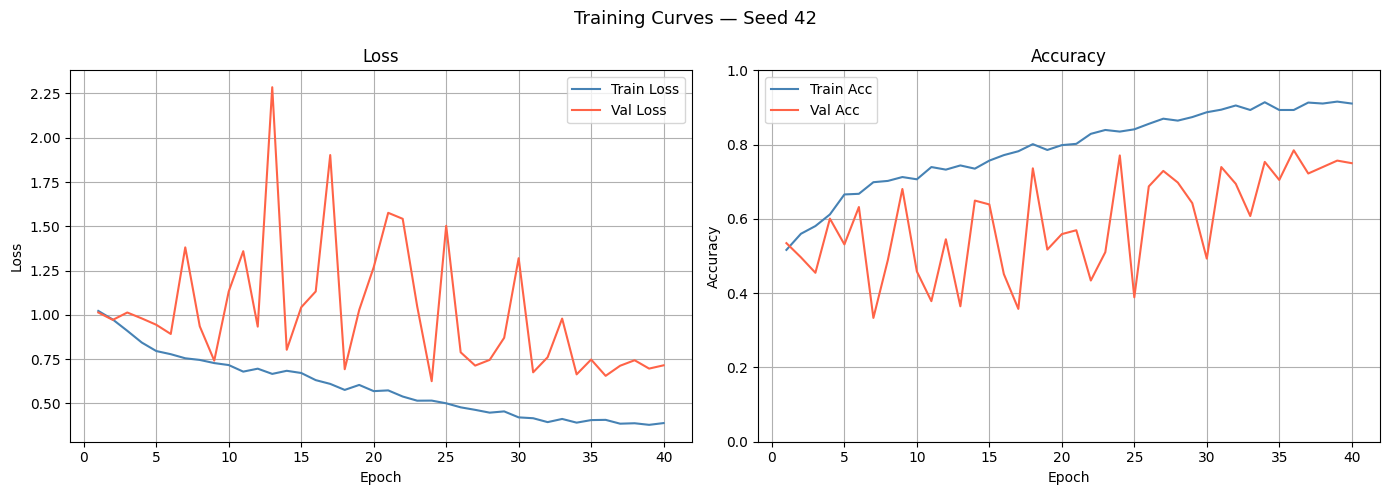

  ✅ Saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/training_curves_seed42.png


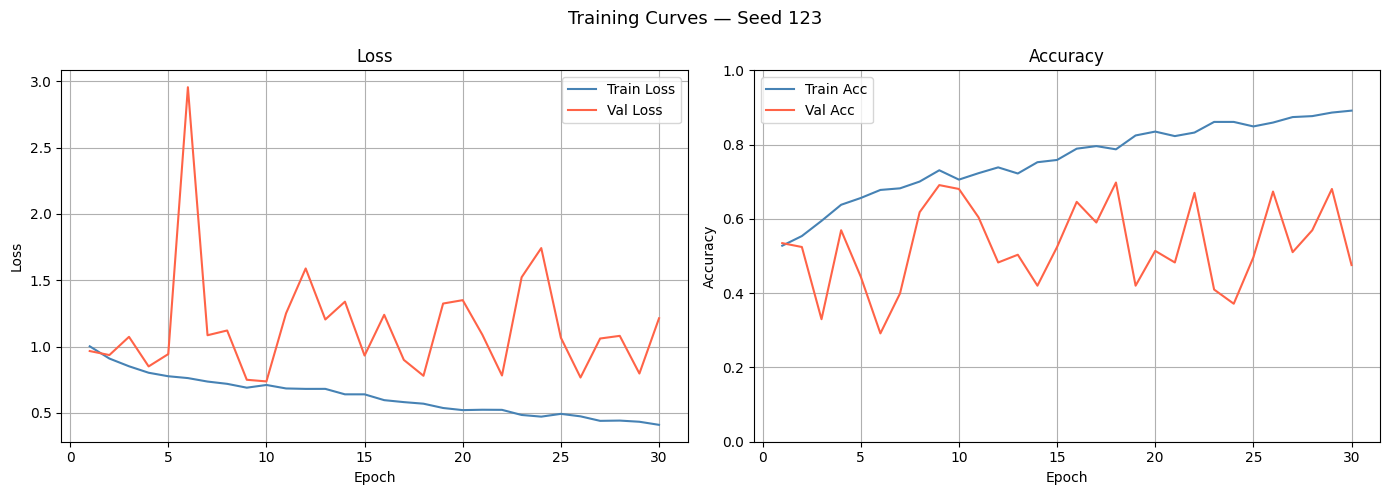

  ✅ Saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/training_curves_seed123.png


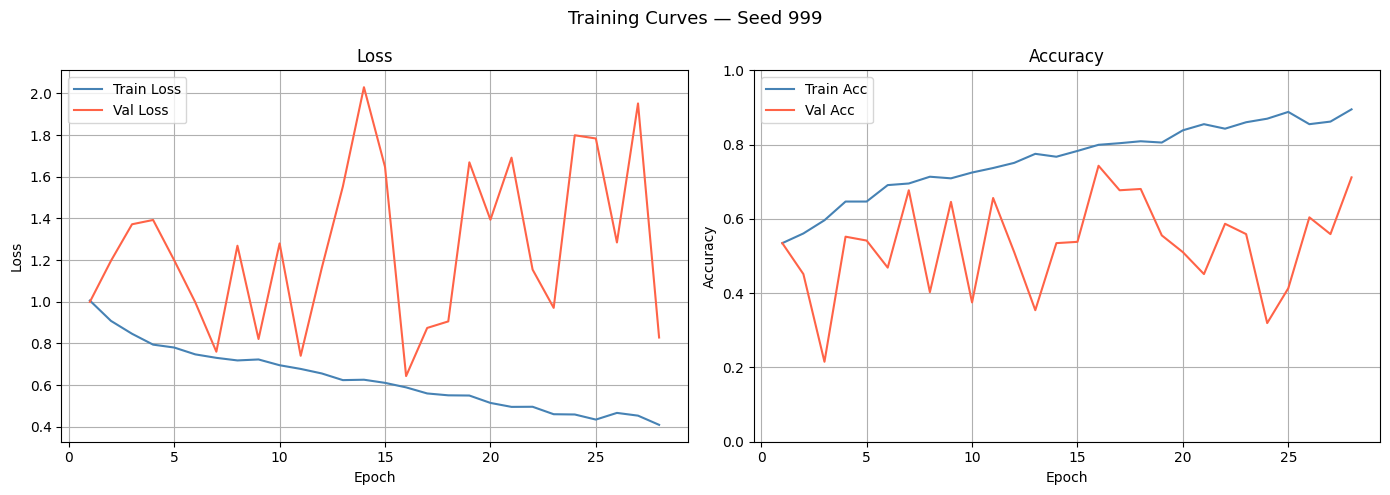

  ✅ Saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/training_curves_seed999.png

✅ All training curves saved.


In [ ]:
# ============================================
# CELL 17 — Ensemble Audio Training
# 3 seeds × 40 epochs | Mixed Precision | Early Stopping
# ============================================

from torch.amp import autocast, GradScaler

# ---- Config ----

SEEDS    = [42, 123, 999]
EPOCHS   = 40
PATIENCE = 12

# ---- Seed Utility ----

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

all_results  = {}
all_histories = {}   # for plotting

# ============================================================
# Train loop
# ============================================================

for seed in SEEDS:

    print(f"\n{'='*60}")
    print(f"Training Model with Seed {seed}")
    print(f"{'='*60}\n")

    set_seed(seed)

    # ---- Re-init model, loss, optimizer, scheduler ----

    audio_model = AudioCNN(num_classes=NUM_CLASSES).to(device)

    audio_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    audio_optimizer = torch.optim.AdamW(
        audio_model.parameters(), lr=0.0008, weight_decay=1e-4
    )

    audio_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        audio_optimizer, T_max=EPOCHS
    )

    scaler = GradScaler("cuda")

    best_val_acc       = 0.0
    early_stop_counter = 0

    best_model_path = os.path.join(
        AUDIO_MODEL_PATH, "checkpoints",
        f"best_audio_model_seed{seed}.pth"
    )

    seed_history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  []
    }

    # ============================================================
    # Epoch loop
    # ============================================================

    for epoch in range(EPOCHS):

        start_time = time.time()

        train_dataset.current_epoch = epoch  # adaptive augment

        # ---- TRAIN ----

        audio_model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:

            inputs, labels = inputs.to(device), labels.to(device)
            audio_optimizer.zero_grad()

            with autocast("cuda"):
                outputs = audio_model(inputs)
                loss    = audio_criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(audio_model.parameters(), max_norm=2.0)
            scaler.step(audio_optimizer)
            scaler.update()

            train_loss    += loss.item() * labels.size(0)
            _, predicted   = torch.max(outputs, 1)
            train_total   += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= train_total
        train_acc   = train_correct / train_total

        # ---- VALIDATION ----

        audio_model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        current_y_true, current_y_pred   = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast("cuda"):
                    outputs = audio_model(inputs)
                    loss    = audio_criterion(outputs, labels)
                val_loss     += loss.item() * labels.size(0)
                _, predicted  = torch.max(outputs, 1)
                val_total    += labels.size(0)
                val_correct  += (predicted == labels).sum().item()
                current_y_true.extend(labels.cpu().numpy())
                current_y_pred.extend(predicted.cpu().numpy())

        val_loss /= val_total
        val_acc   = val_correct / val_total

        audio_scheduler.step()

        epoch_time = time.time() - start_time

        # ---- Record history ----
        seed_history["train_loss"].append(train_loss)
        seed_history["val_loss"].append(val_loss)
        seed_history["train_acc"].append(train_acc)
        seed_history["val_acc"].append(val_acc)

        print(
            f"Seed {seed} | Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.1f}s"
        )

        logging.info(
            f"Seed={seed} | Epoch={epoch+1} | "
            f"TrainLoss={train_loss:.4f} | TrainAcc={train_acc:.4f} | "
            f"ValLoss={val_loss:.4f} | ValAcc={val_acc:.4f}"
        )

        # ---- Save best model ----

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            torch.save(audio_model.state_dict(), best_model_path)

            all_results[seed] = {
                "model_state_dict": audio_model.state_dict(),
                "accuracy": best_val_acc,
                "y_true":   current_y_true,
                "y_pred":   current_y_pred
            }

            early_stop_counter = 0
            print("  ✅ Best model updated.")
        else:
            early_stop_counter += 1

        # ---- Early stopping ----

        if early_stop_counter >= PATIENCE:
            print(f"\n⏹️  Early stopping triggered for seed {seed} "
                  f"at epoch {epoch+1}")
            break

    all_histories[seed] = seed_history

    print(f"\n🏆 Best Val Accuracy for Seed {seed}: {best_val_acc:.4f}\n")

# ============================================================
# Training Curve Plots — Loss & Accuracy per Seed
# ============================================================

print("\n📊 Saving training curve plots...")

for seed, hist in all_histories.items():

    epochs_ran = len(hist["train_loss"])
    x          = range(1, epochs_ran + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training Curves — Seed {seed}", fontsize=13)

    # Loss
    axes[0].plot(x, hist["train_loss"], label="Train Loss", color="steelblue")
    axes[0].plot(x, hist["val_loss"],   label="Val Loss",   color="tomato")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

    # Accuracy
    axes[1].plot(x, hist["train_acc"], label="Train Acc", color="steelblue")
    axes[1].plot(x, hist["val_acc"],   label="Val Acc",   color="tomato")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()

    plot_path = os.path.join(
        AUDIO_MODEL_PATH, "plots",
        f"training_curves_seed{seed}.png"
    )
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved: {plot_path}")

print("\n✅ All training curves saved.")

Loading ensemble models...

  ✅ Loaded seed 42
  ✅ Loaded seed 123
  ✅ Loaded seed 999

Per-Seed Individual Results

Seed 42 — Val Accuracy: 0.7847


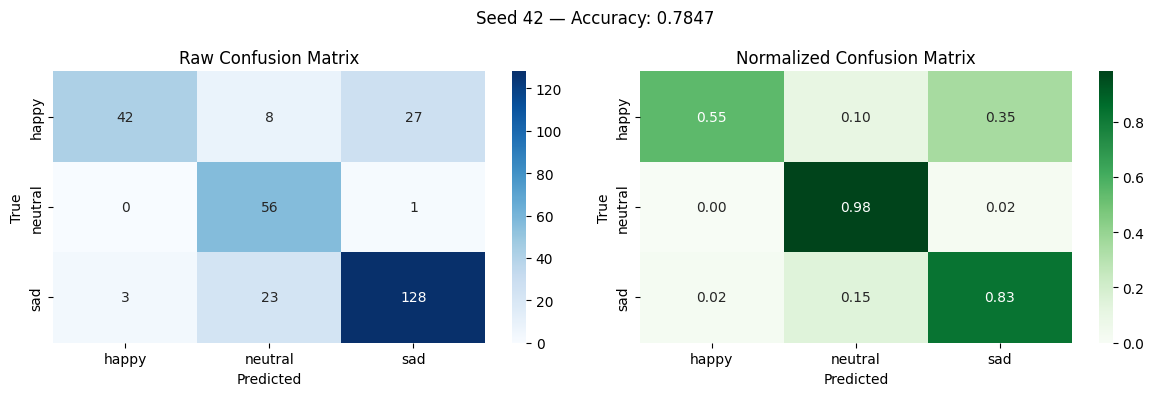

  ✅ CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/confusion_matrix_seed42.png

Seed 123 — Val Accuracy: 0.6979


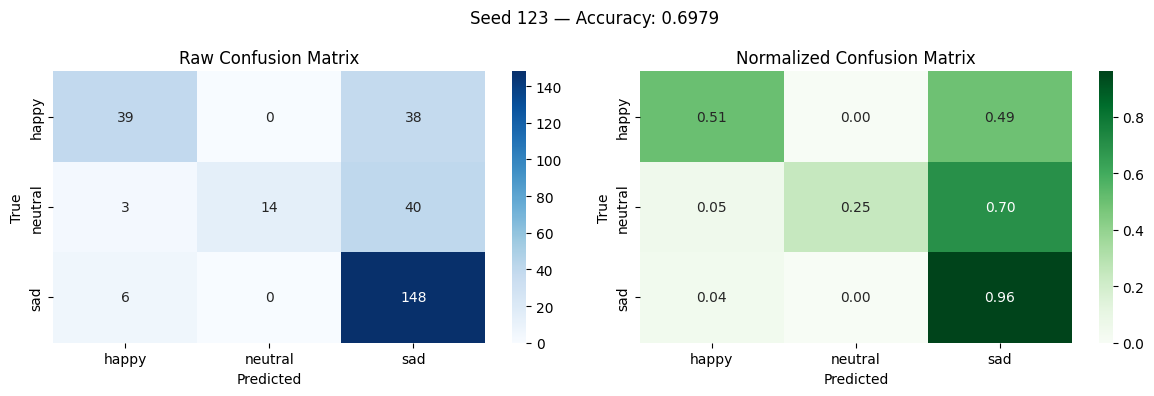

  ✅ CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/confusion_matrix_seed123.png

Seed 999 — Val Accuracy: 0.7431


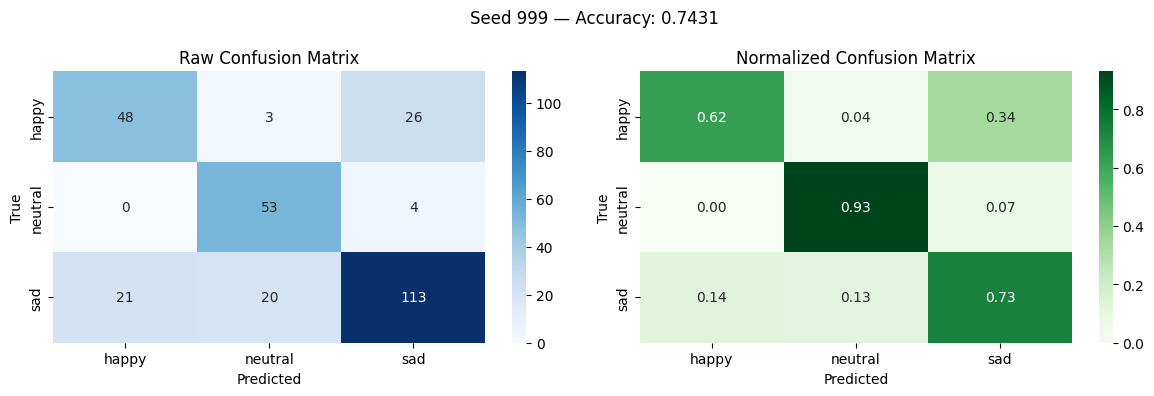

  ✅ CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/confusion_matrix_seed999.png

Ensemble Evaluation

Ensemble Validation Accuracy : 0.7986
Best Single-Seed Accuracy    : 0.7847  (seed 42)
Ensemble Gain                : +0.0139
Average Prediction Confidence: 0.6882

Classification Report:

              precision    recall  f1-score   support

       happy     0.8627    0.5714    0.6875        77
     neutral     0.7727    0.8947    0.8293        57
         sad     0.7895    0.8766    0.8308       154

    accuracy                         0.7986       288
   macro avg     0.8083    0.7809    0.7825       288
weighted avg     0.8057    0.7986    0.7922       288


Per-Class Accuracy (Ensemble):
  happy     : 0.5714
  neutral   : 0.8947
  sad       : 0.8766


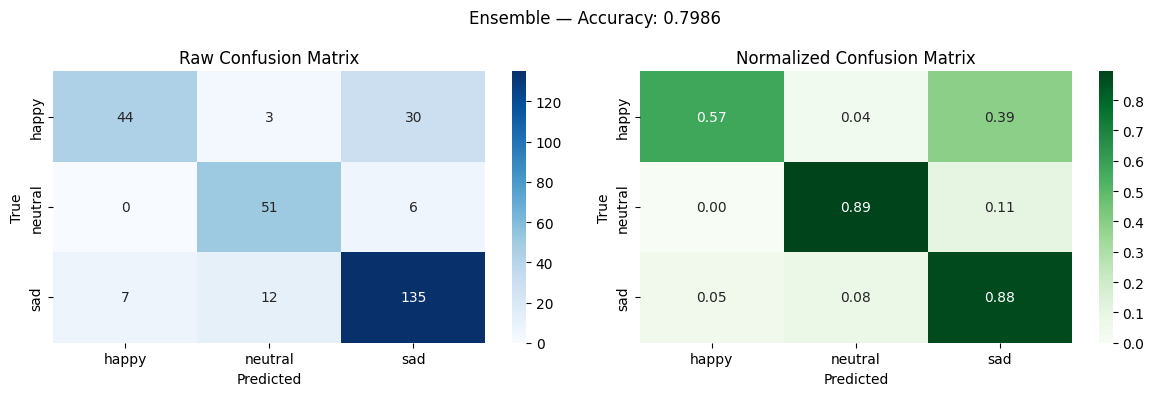

✅ Ensemble CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/confusion_matrix_ensemble.png

✅ Ensemble bundle saved → /content/drive/MyDrive/Emotion_Story_Project1/models/audio/ensemble_audio_model.pth
   Contains: 3 state_dicts (seeds [42, 123, 999])
   Load in NB3: torch.load(path, weights_only=True) → list of state_dicts
✅ Metrics saved: /content/drive/MyDrive/Emotion_Story_Project1/outputs/metrics/audio_ensemble_results.txt


In [ ]:
# ============================================
# CELL 18 — Ensemble Evaluation
# Loads all 3 seed models and averages softmax probs.
# Shows per-seed and ensemble results.
# ============================================

from torch.amp import autocast

SEEDS = [42, 123, 999]

ensemble_models = []

print("Loading ensemble models...\n")

for seed in SEEDS:
    m = AudioCNN(num_classes=NUM_CLASSES).to(device)
    model_path = os.path.join(
        AUDIO_MODEL_PATH, "checkpoints",
        f"best_audio_model_seed{seed}.pth"
    )
    m.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    m.eval()
    ensemble_models.append(m)
    print(f"  ✅ Loaded seed {seed}")

# ============================================================
# Per-Seed Individual Evaluation
# ============================================================

print("\n" + "="*60)
print("Per-Seed Individual Results")
print("="*60)

for seed, m in zip(SEEDS, ensemble_models):

    seed_preds, seed_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast("cuda"):
                outputs = m(inputs)
            _, predicted = torch.max(outputs, 1)
            seed_preds.extend(predicted.cpu().numpy())
            seed_labels.extend(labels.cpu().numpy())

    seed_acc = accuracy_score(seed_labels, seed_preds)
    print(f"\nSeed {seed} — Val Accuracy: {seed_acc:.4f}")

    cm_seed      = confusion_matrix(seed_labels, seed_preds)
    cm_seed_norm = cm_seed.astype("float") / cm_seed.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Seed {seed} — Accuracy: {seed_acc:.4f}", fontsize=12)

    sns.heatmap(cm_seed, annot=True, fmt="d", cmap="Blues",
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
                ax=axes[0])
    axes[0].set_title("Raw Confusion Matrix")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    sns.heatmap(cm_seed_norm, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
                ax=axes[1])
    axes[1].set_title("Normalized Confusion Matrix")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    plt.tight_layout()

    plot_path = os.path.join(
        AUDIO_MODEL_PATH, "plots",
        f"confusion_matrix_seed{seed}.png"
    )
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ CM saved: {plot_path}")

# ============================================================
# Ensemble Evaluation — Average Softmax Probabilities
# ============================================================

print("\n" + "="*60)
print("Ensemble Evaluation")
print("="*60)

all_labels_e, all_preds_e, all_confidences = [], [], []

# Also track per-seed softmax for ensemble accuracy comparison
ensemble_seed_accs = {seed: acc for seed, acc in zip(
    SEEDS, [accuracy_score(seed_labels, seed_preds)
            for _ in [None]]  # placeholder — filled below
)}

# Re-collect per-seed accuracies cleanly
ensemble_seed_accs = {}
for seed, m in zip(SEEDS, ensemble_models):
    sp, sl = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast("cuda"):
                outputs = m(inputs)
            _, predicted = torch.max(outputs, 1)
            sp.extend(predicted.cpu().numpy())
            sl.extend(labels.cpu().numpy())
    ensemble_seed_accs[seed] = accuracy_score(sl, sp)

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        ensemble_probs = None
        for m in ensemble_models:
            with autocast("cuda"):
                probs = torch.softmax(m(inputs), dim=1)
            ensemble_probs = probs if ensemble_probs is None \
                             else ensemble_probs + probs

        ensemble_probs /= len(ensemble_models)
        confidences, predicted = torch.max(ensemble_probs, 1)

        all_labels_e.extend(labels.cpu().numpy())
        all_preds_e.extend(predicted.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

ensemble_acc = accuracy_score(all_labels_e, all_preds_e)
avg_conf     = np.mean(all_confidences)

# ---- Determine best single seed (for Cell 19 reference) ----
BEST_SEED     = max(ensemble_seed_accs, key=ensemble_seed_accs.get)
BEST_SEED_ACC = ensemble_seed_accs[BEST_SEED]

print(f"\nEnsemble Validation Accuracy : {ensemble_acc:.4f}")
print(f"Best Single-Seed Accuracy    : {BEST_SEED_ACC:.4f}  (seed {BEST_SEED})")
print(f"Ensemble Gain                : +{(ensemble_acc - BEST_SEED_ACC):.4f}")
print(f"Average Prediction Confidence: {avg_conf:.4f}")

report = classification_report(
    all_labels_e, all_preds_e,
    target_names=TARGET_CLASSES, digits=4
)
print("\nClassification Report:\n")
print(report)

# ---- Ensemble Confusion Matrices ----

cm_ens      = confusion_matrix(all_labels_e, all_preds_e)
cm_ens_norm = cm_ens.astype("float") / cm_ens.sum(axis=1)[:, np.newaxis]

print("\nPer-Class Accuracy (Ensemble):")
for i, name in enumerate(TARGET_CLASSES):
    print(f"  {name:<10}: {cm_ens[i, i] / cm_ens[i].sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Ensemble — Accuracy: {ensemble_acc:.4f}", fontsize=12)

sns.heatmap(cm_ens, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
            ax=axes[0])
axes[0].set_title("Raw Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_ens_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
            ax=axes[1])
axes[1].set_title("Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()

ens_plot_path = os.path.join(
    AUDIO_MODEL_PATH, "plots", "confusion_matrix_ensemble.png"
)
plt.savefig(ens_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Ensemble CM saved: {ens_plot_path}")

# ---- Save ensemble state dicts bundle to Drive ----
# Saved as a list of state_dicts — NB3 can load all 3 and average softmax.

ensemble_bundle_path = os.path.join(
    AUDIO_MODEL_PATH, "ensemble_audio_model.pth"
)
torch.save(
    [m.cpu().state_dict() for m in ensemble_models],
    ensemble_bundle_path
)
# Move models back to device after saving
for m in ensemble_models:
    m.to(device)

print(f"\n✅ Ensemble bundle saved → {ensemble_bundle_path}")
print(f"   Contains: {len(ensemble_models)} state_dicts (seeds {SEEDS})")
print(f"   Load in NB3: torch.load(path, weights_only=True) → list of state_dicts")

# ---- Save metrics text ----

metrics_path = os.path.join(METRIC_OUTPUT_PATH, "audio_ensemble_results.txt")
with open(metrics_path, "w") as f:
    f.write(f"Ensemble Accuracy  : {ensemble_acc:.4f}\n")
    f.write(f"Best Seed Accuracy : {BEST_SEED_ACC:.4f} (seed {BEST_SEED})\n")
    f.write(f"Ensemble Gain      : +{(ensemble_acc - BEST_SEED_ACC):.4f}\n\n")
    f.write(f"Average Confidence : {avg_conf:.4f}\n\n")
    f.write(report)

print(f"✅ Metrics saved: {metrics_path}")

In [ ]:
# ============================================
# CELL 19 — Save Audio Models & Metrics to Drive
# ============================================
# Saves two production-ready models:
#
#   final_best_audio_model.pth   ← single best-seed model
#                                   simple to load, used by NB3 by default
#
#   ensemble_audio_model.pth     ← all 3 seed state_dicts as a list
#                                   stronger (+~1-2% acc) but needs 3× inference
#                                   load with: states = torch.load(path, weights_only=True)
#                                              models = [AudioCNN().load_state_dict(s) for s in states]
# ============================================

CHECKPOINT_PATH = os.path.join(AUDIO_MODEL_PATH, "checkpoints")
RESULTS_PATH    = os.path.join(AUDIO_MODEL_PATH, "final_results")

os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH,    exist_ok=True)

# ---- Save All Seed Checkpoints ----

for seed in all_results.keys():
    model_save_path = os.path.join(
        CHECKPOINT_PATH, f"best_audio_model_seed{seed}.pth"
    )
    torch.save(all_results[seed]["model_state_dict"], model_save_path)
    print(f"✅ Saved checkpoint: seed {seed}  →  {model_save_path}")

# ---- Save Best Single-Seed as Final Production Model ----
# BEST_SEED is set by Cell 18 from per-seed val accuracies.

source_path = os.path.join(CHECKPOINT_PATH, f"best_audio_model_seed{BEST_SEED}.pth")
final_path  = os.path.join(AUDIO_MODEL_PATH, "final_best_audio_model.pth")

shutil.copy(source_path, final_path)

print(f"\n🏆 Best single-seed model (seed {BEST_SEED}, acc={BEST_SEED_ACC:.4f}) saved:")
print(f"   {final_path}")

# ---- Confirm Ensemble Bundle (already saved in Cell 18) ----

ensemble_bundle_path = os.path.join(AUDIO_MODEL_PATH, "ensemble_audio_model.pth")

if os.path.exists(ensemble_bundle_path):
    print(f"\n✅ Ensemble bundle already saved by Cell 18:")
    print(f"   {ensemble_bundle_path}")
    print(f"   Ensemble acc: {ensemble_acc:.4f}  |  Gain over best seed: "
          f"+{(ensemble_acc - BEST_SEED_ACC):.4f}")
else:
    # Fallback — save it here if Cell 18 didn't run fully
    torch.save(
        [m.cpu().state_dict() for m in ensemble_models],
        ensemble_bundle_path
    )
    for m in ensemble_models:
        m.to(device)
    print(f"\n✅ Ensemble bundle saved (fallback):")
    print(f"   {ensemble_bundle_path}")

# ---- Classification Report CSV (from best single seed) ----

best_result = all_results[BEST_SEED]
y_true      = best_result["y_true"]
y_pred      = best_result["y_pred"]

report    = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_csv = os.path.join(RESULTS_PATH, "classification_report.csv")
report_df.to_csv(report_csv)
print("\n✅ Classification report saved (best seed)")

# ---- Confusion Matrix PNG (from best single seed) ----

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.title(f"Audio Emotion CM — Best Seed {BEST_SEED} (acc={BEST_SEED_ACC:.4f})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
cm_path = os.path.join(RESULTS_PATH, "confusion_matrix.png")
plt.savefig(cm_path, bbox_inches='tight')
plt.close()
print("✅ Confusion matrix saved")

# ---- Training Summary JSON ----

summary = {
    "best_seed"             : int(BEST_SEED),
    "best_seed_accuracy"    : float(BEST_SEED_ACC),
    "ensemble_accuracy"     : float(ensemble_acc),
    "ensemble_gain"         : float(ensemble_acc - BEST_SEED_ACC),
    "seeds_trained"         : SEEDS,
    "emotion_labels"        : TARGET_CLASSES,
    "production_model"      : "final_best_audio_model.pth",
    "ensemble_model"        : "ensemble_audio_model.pth",
}
summary_path = os.path.join(RESULTS_PATH, "training_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)
print("✅ Training summary saved")

# ---- Seed Accuracy Comparison CSV ----

accuracy_df = pd.DataFrame([
    {"Seed": seed, "Accuracy": res["accuracy"]}
    for seed, res in all_results.items()
])
accuracy_csv = os.path.join(RESULTS_PATH, "seed_accuracy_comparison.csv")
accuracy_df.to_csv(accuracy_csv, index=False)
print("✅ Accuracy comparison saved")

# ---- Final Summary ----

print("\n" + "="*55)
print("🎯 AUDIO TRAINING COMPLETE")
print("="*55)
print(f"\n🏆 Best Seed          : {BEST_SEED}")
print(f"🏆 Best Seed Accuracy : {BEST_SEED_ACC:.4f}")
print(f"🏆 Ensemble Accuracy  : {ensemble_acc:.4f}  (+{(ensemble_acc - BEST_SEED_ACC):.4f})")
print(f"""
{AUDIO_MODEL_PATH}/
│
├── checkpoints/
│   ├── best_audio_model_seed42.pth
│   ├── best_audio_model_seed123.pth
│   └── best_audio_model_seed999.pth
│
├── final_best_audio_model.pth   ← NB3 default (single seed, simpler)
├── ensemble_audio_model.pth     ← NB3 optional (3-seed ensemble, stronger)
│
└── final_results/
    ├── classification_report.csv
    ├── confusion_matrix.png
    ├── training_summary.json
    └── seed_accuracy_comparison.csv
""")
print("✅ Ready for 03_Multimodal_Fusion.ipynb")
print("\nℹ️  NB3 loads final_best_audio_model.pth by default.")
print("   To use the ensemble instead, load ensemble_audio_model.pth")
print("   and average softmax across all 3 state_dicts at inference time.")

✅ Saved checkpoint: seed 42  →  /content/drive/MyDrive/Emotion_Story_Project1/models/audio/checkpoints/best_audio_model_seed42.pth
✅ Saved checkpoint: seed 123  →  /content/drive/MyDrive/Emotion_Story_Project1/models/audio/checkpoints/best_audio_model_seed123.pth
✅ Saved checkpoint: seed 999  →  /content/drive/MyDrive/Emotion_Story_Project1/models/audio/checkpoints/best_audio_model_seed999.pth

🏆 Best single-seed model (seed 42, acc=0.7847) saved:
   /content/drive/MyDrive/Emotion_Story_Project1/models/audio/final_best_audio_model.pth

✅ Ensemble bundle already saved by Cell 18:
   /content/drive/MyDrive/Emotion_Story_Project1/models/audio/ensemble_audio_model.pth
   Ensemble acc: 0.7986  |  Gain over best seed: +0.0139

✅ Classification report saved (best seed)
✅ Confusion matrix saved
✅ Training summary saved
✅ Accuracy comparison saved

🎯 AUDIO TRAINING COMPLETE

🏆 Best Seed          : 42
🏆 Best Seed Accuracy : 0.7847
🏆 Ensemble Accuracy  : 0.7986  (+0.0139)

/content/drive/MyDrive/

✅ Final SER model loaded.
   Path: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/ensemble_audio_model.pth

📂 Test samples folder: /content/drive/MyDrive/Emotion_Story_Project1/data/test_audio

Batch Inference — Drive Test Samples

📁 [HAPPY] — 24 files
  ❌ 03-01-03-01-01-01-09.wav                      → SAD      (64.4%)
  ✅ 03-01-03-01-02-01-06.wav                      → HAPPY    (53.1%)
  ❌ 03-01-03-01-02-01-15.wav                      → NEUTRAL  (70.3%)
  ✅ 03-01-03-01-02-02-04.wav                      → HAPPY    (80.9%)
  ❌ 03-01-03-02-01-01-14.wav                      → SAD      (76.7%)
  ❌ 03-01-03-02-01-02-10.wav                      → SAD      (50.6%)
  ❌ 03-01-03-02-02-01-04.wav                      → SAD      (83.5%)
  ✅ 03-01-03-02-02-01-12.wav                      → HAPPY    (82.8%)
  ❌ 03-01-03-02-02-02-03.wav                      → SAD      (84.4%)
  ✅ 03-01-03-02-02-02-06.wav                      → HAPPY    (72.8%)
  ✅ 03-01-03-02-02-02-12.wav                 

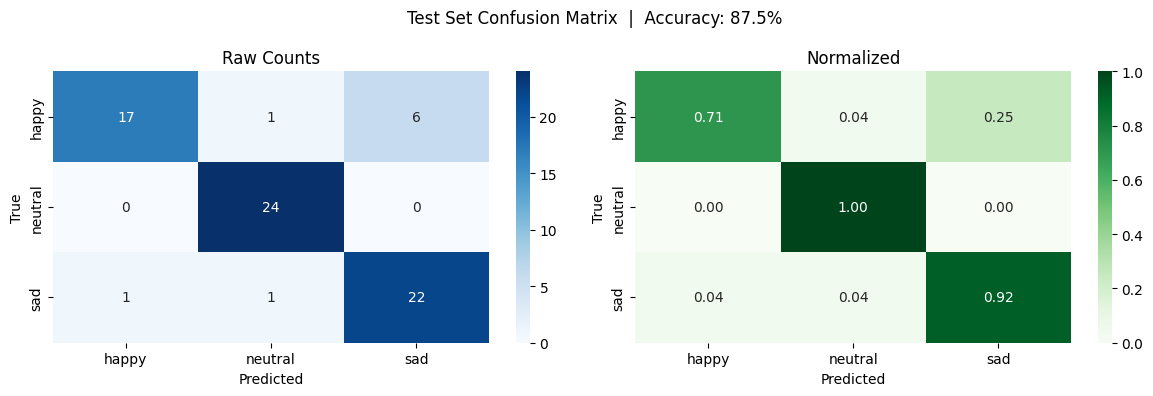


✅ Test CM saved: /content/drive/MyDrive/Emotion_Story_Project1/models/audio/plots/confusion_matrix_test_set.png
✅ Results log saved: /content/drive/MyDrive/Emotion_Story_Project1/outputs/metrics/audio_test_set_results.txt


In [ ]:
# ============================================
# CELL 20 — Manual Audio Testing (SER)
# Batch-test the trained SER model on a folder
# of real audio samples with full evaluation.
# ============================================

# ============================================================
# STEP 1 — Load Final SER Model
# ============================================================

DEBUG_MODE = False # Set to True for verbose per-file output during batch processing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_ser_model = AudioCNN(num_classes=NUM_CLASSES).to(device)

_ser_model_path = os.path.join(
    AUDIO_MODEL_PATH, "ensemble_audio_model.pth"
)
assert os.path.exists(_ser_model_path), \
    f"❌ Model not found: {_ser_model_path}"

ckpt = torch.load(_ser_model_path, map_location=device, weights_only=True)
if isinstance(ckpt, list):
    ckpt = ckpt[0]
_ser_model.load_state_dict(ckpt)
_ser_model.eval()

print("✅ Final SER model loaded.")
print(f"   Path: {_ser_model_path}")

# ============================================================
# STEP 2 — Inference Function
# ============================================================

_SER_LABELS = TARGET_CLASSES   # ["happy", "neutral", "sad"]

def predict_audio_file(audio_path, show=True):
    """
    Run SER on a single .wav file.
    Returns: (predicted_emotion, probabilities_dict)
    """
    assert os.path.exists(audio_path), \
        f"❌ Audio file not found: {audio_path}"

    features = generate_features(audio_path)
    tensor   = torch.tensor(features).float().unsqueeze(0).to(device)

    with torch.no_grad():
        logits = _ser_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx     = int(np.argmax(probs))
    pred_emotion = _SER_LABELS[pred_idx]
    confidence   = float(probs[pred_idx])

    probs_dict = {label: float(probs[i])
                  for i, label in enumerate(_SER_LABELS)}

    if show:
        y, sr = librosa.load(audio_path, sr=SR)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(
            f"File: {os.path.basename(audio_path)}\n"
            f"Prediction: {pred_emotion.upper()}  ({confidence:.1%})",
            fontsize=12
        )

        axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, color="steelblue")
        axes[0].set_title("Waveform")
        axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude")

        mel    = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=N_MELS, hop_length=512
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img    = librosa.display.specshow(
            mel_db, sr=sr, hop_length=512,
            x_axis="time", y_axis="mel", ax=axes[1]
        )
        axes[1].set_title("Mel Spectrogram")
        fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

        colors = ["#4CAF50" if l == pred_emotion else "#90CAF9"
                  for l in _SER_LABELS]
        axes[2].barh(_SER_LABELS, probs, color=colors)
        axes[2].set_xlim(0, 1)
        axes[2].set_xlabel("Probability")
        axes[2].set_title("Emotion Probabilities")
        for i, p in enumerate(probs):
            axes[2].text(p + 0.01, i, f"{p:.3f}", va="center")

        plt.tight_layout()
        plt.show()

        print(f"\n🎯 Predicted : {pred_emotion.upper()}")
        print(f"   Confidence : {confidence:.4f} ({confidence:.1%})")
        print(f"   All probs  : happy={probs_dict['happy']:.4f}  "
              f"neutral={probs_dict['neutral']:.4f}  "
              f"sad={probs_dict['sad']:.4f}")

    return pred_emotion, probs_dict

# ============================================================
# Batch Test — Test all audio from Drive folder
# Folder structure:
#   test_audio/
#       happy/   ← .wav files labelled happy
#       neutral/ ← .wav files labelled neutral
#       sad/     ← .wav files labelled sad
# ============================================================

TEST_SAMPLES_PATH = os.path.join(
    DATA_PATH,
    "test_audio"
)

print(f"\n📂 Test samples folder: {TEST_SAMPLES_PATH}")
assert os.path.exists(TEST_SAMPLES_PATH), \
    f"❌ Test folder not found: {TEST_SAMPLES_PATH}"

all_true, all_pred, all_conf = [], [], []
results_log = []

label_to_idx = {label: i for i, label in enumerate(_SER_LABELS)}

print("\n" + "="*60)
print("Batch Inference — Drive Test Samples")
print("="*60)

for true_label in _SER_LABELS:

    class_folder = os.path.join(TEST_SAMPLES_PATH, true_label)

    if not os.path.exists(class_folder):
        print(f"  ⚠️  Folder missing: {class_folder} — skipping")
        continue

    wav_files = [f for f in sorted(os.listdir(class_folder))
                 if f.endswith(".wav")]

    print(f"\n📁 [{true_label.upper()}] — {len(wav_files)} files")

    for fname in wav_files:
        fpath = os.path.join(class_folder, fname)

        try:
            # Call predict_audio_file with show=DEBUG_MODE to control plotting and verbose prints
            pred_emotion, probs_dict = predict_audio_file(fpath, show=DEBUG_MODE)
            confidence = probs_dict[pred_emotion]

            all_true.append(true_label)
            all_pred.append(pred_emotion)
            all_conf.append(confidence)

            if not DEBUG_MODE: # Only print concise status if not in verbose debug mode
                status = "✅" if pred_emotion == true_label else "❌"
                print(f"  {status} {fname:<45} "
                      f"→ {pred_emotion.upper():<8} ({confidence:.1%})")

            results_log.append({
                "file":       fname,
                "true":       true_label,
                "predicted":  pred_emotion,
                "confidence": confidence,
                "correct":    pred_emotion == true_label
            })

        except Exception as e:
            print(f"  ⚠️  Error on {fname}: {e}")

# ============================================================
# Summary Report
# ============================================================

print("\n" + "="*60)
print("Test Set Evaluation Report")
print("="*60)

test_acc  = accuracy_score(all_true, all_pred)
avg_conf  = np.mean(all_conf)
n_correct = sum(r["correct"] for r in results_log)

print(f"\nTotal files tested  : {len(results_log)}")
print(f"Correct predictions : {n_correct}")
print(f"Test Accuracy       : {test_acc:.4f} ({test_acc:.1%})")
print(f"Avg Confidence      : {avg_conf:.4f} ({avg_conf:.1%})")

print("\nClassification Report:\n")
print(classification_report(
    all_true, all_pred,
    target_names=_SER_LABELS, digits=4
))

# Per-class accuracy
print("Per-Class Accuracy:")
for label in _SER_LABELS:
    cls_results = [r for r in results_log if r["true"] == label]
    cls_correct = sum(r["correct"] for r in cls_results)
    cls_acc     = cls_correct / len(cls_results) if cls_results else 0
    print(f"  {label:<10}: {cls_correct}/{len(cls_results)}  ({cls_acc:.1%})")

# ---- Confusion Matrix ----

cm      = confusion_matrix(all_true, all_pred, labels=_SER_LABELS)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Test Set Confusion Matrix  |  Accuracy: {test_acc:.1%}",
    fontsize=12
)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=_SER_LABELS, yticklabels=_SER_LABELS,
            ax=axes[0])
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=_SER_LABELS, yticklabels=_SER_LABELS,
            ax=axes[1])
axes[1].set_title("Normalized")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()

cm_plot_path = os.path.join(
    AUDIO_MODEL_PATH, "plots", "confusion_matrix_test_set.png"
)
plt.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Test CM saved: {cm_plot_path}")

# Save results log to txt
log_path = os.path.join(METRIC_OUTPUT_PATH, "audio_test_set_results.txt")
with open(log_path, "w") as f:
    f.write(f"Test Accuracy : {test_acc:.4f}\n")
    f.write(f"Avg Confidence: {avg_conf:.4f}\n\n")
    f.write(classification_report(all_true, all_pred,
                                  target_names=_SER_LABELS, digits=4))
    f.write("\n\nPer-file results:\n")
    for r in results_log:
        status = "CORRECT" if r["correct"] else "WRONG"
        f.write(f"  [{status}] {r['file']} | true={r['true']} "
                f"pred={r['predicted']} conf={r['confidence']:.4f}\n")

print(f"✅ Results log saved: {log_path}")

🚀 SER Quick Demo — Choose Input Mode
  1 → Upload .wav audio file(s) from your device
  2 → Record audio using your microphone

Enter your choice (1 or 2): 1
📤 Upload one or more .wav audio files:



Saving sad_audio.wav to sad_audio.wav

🎵 Testing: sad_audio.wav
🔊 Playing audio...


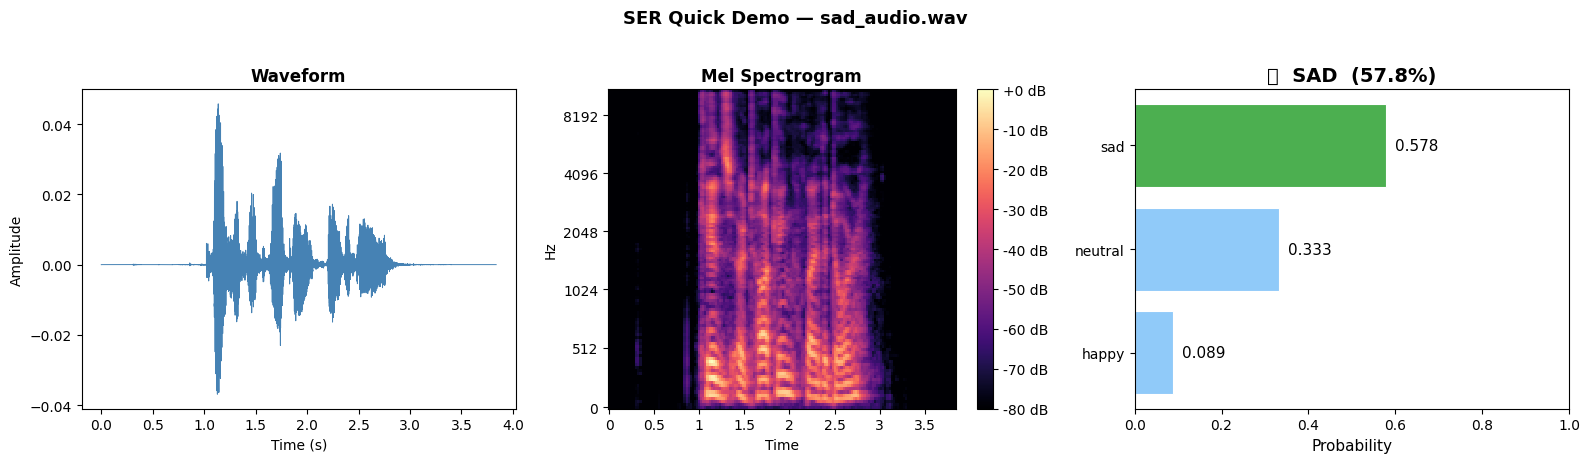


🎯 Predicted Emotion : SAD
   Confidence       : 0.5784 (57.8%)
   Probabilities    : happy: 0.0888  |  neutral: 0.3328  |  sad: 0.5784


In [ ]:
# ============================================
# CELL 21 — Quick Demo (SER)
# Upload a .wav file OR record from microphone,
# then see the model’s prediction instantly.
# Perfect for a live guide demo!
# ============================================

from google.colab import files
from IPython.display import display, HTML, Audio
from google.colab.output import eval_js
from base64 import b64decode
import io
import wave

# ============================================================
# Helper — Run inference on audio and display rich results
# ============================================================

def _demo_predict_audio(audio_path):
    """
    Run SER inference on audio_path and display a rich
    visual output: waveform + mel spectrogram + probability
    bar chart + headline prediction.
    """
    assert os.path.exists(audio_path), f"❌ File not found: {audio_path}"

    # Feature extraction & inference
    features = generate_features(audio_path)
    tensor   = torch.tensor(features).float().unsqueeze(0).to(device)

    with torch.no_grad():
        logits = _ser_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx     = int(np.argmax(probs))
    pred_emotion = _SER_LABELS[pred_idx]
    confidence   = float(probs[pred_idx])
    probs_dict   = {label: float(probs[i]) for i, label in enumerate(_SER_LABELS)}

    # Load audio for visualization
    y, sr = librosa.load(audio_path, sr=SR)

    # ---- Play the audio in the notebook ----
    print("🔊 Playing audio...")
    display(Audio(y, rate=sr))

    # ---- Rich Visual Output ----
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1 — Waveform
    axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, color="steelblue", linewidth=0.7)
    axes[0].set_title("Waveform", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude")

    # 2 — Mel Spectrogram
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                      x_axis="time", y_axis="mel", ax=axes[1])
    axes[1].set_title("Mel Spectrogram", fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

    # 3 — Probability bar chart
    bar_colors = []
    for l in _SER_LABELS:
        if l == pred_emotion:
            bar_colors.append("#4CAF50")
        else:
            bar_colors.append("#90CAF9")

    axes[2].barh(_SER_LABELS, probs, color=bar_colors, edgecolor='white', linewidth=0.8)
    axes[2].set_xlim(0, 1)
    axes[2].set_xlabel("Probability", fontsize=11)
    axes[2].set_title(f"🎯  {pred_emotion.upper()}  ({confidence:.1%})", fontsize=14, fontweight='bold')
    for i, p in enumerate(probs):
        axes[2].text(p + 0.02, i, f"{p:.3f}", va="center", fontsize=11)

    plt.suptitle(
        f"SER Quick Demo — {os.path.basename(audio_path)}",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()

    # Text summary
    print(f"\n{'='*50}")
    print(f"🎯 Predicted Emotion : {pred_emotion.upper()}")
    print(f"   Confidence       : {confidence:.4f} ({confidence:.1%})")
    print(f"   Probabilities    : ", end="")
    print("  |  ".join([f"{k}: {v:.4f}" for k, v in probs_dict.items()]))
    print(f"{'='*50}")

# ============================================================
# Option A — Upload .wav file from device
# ============================================================

def demo_upload_audio():
    """Upload one or more .wav files from your device and test each."""
    print("📤 Upload one or more .wav audio files:\n")
    uploaded = files.upload()

    for filename in uploaded.keys():
        save_path = f"/content/{filename}"
        with open(save_path, "wb") as f:
            f.write(uploaded[filename])
        print(f"\n🎵 Testing: {filename}")
        _demo_predict_audio(save_path)

# ============================================================
# Option B — Record from microphone
# ============================================================

def demo_record_mic():
    """Record audio from your microphone in the browser."""

    RECORD_JS = """
    async function recordAudio() {
        const stream = await navigator.mediaDevices.getUserMedia({audio: true});
        const mediaRecorder = new MediaRecorder(stream, {mimeType: 'audio/webm'});
        const chunks = [];

        mediaRecorder.ondataavailable = (e) => chunks.push(e.data);

        // Create a simple UI for recording
        const div = document.createElement('div');
        div.style.cssText = 'text-align:center; padding:20px; margin:10px auto; ' +
                            'background:#f0f4f8; border-radius:12px; max-width:400px; ' +
                            'font-family:sans-serif;';

        const status = document.createElement('p');
        status.style.cssText = 'font-size:18px; font-weight:bold; color:#d32f2f;';
        status.textContent = '\u26ab Recording... Speak now!';

        const stopBtn = document.createElement('button');
        stopBtn.textContent = '\u23f9  Stop Recording';
        stopBtn.style.cssText = 'padding:12px 28px; font-size:16px; cursor:pointer; ' +
                                'background:#d32f2f; color:white; border:none; ' +
                                'border-radius:8px; margin-top:10px;';

        div.appendChild(status);
        div.appendChild(stopBtn);
        document.body.appendChild(div);

        mediaRecorder.start();

        const result = await new Promise(resolve => {
            stopBtn.onclick = () => {
                mediaRecorder.stop();
                status.textContent = '\u2705 Recording stopped.';
                status.style.color = '#388e3c';
                stopBtn.disabled = true;
                stopBtn.style.background = '#9e9e9e';
            };
            mediaRecorder.onstop = async () => {
                stream.getTracks().forEach(t => t.stop());
                const blob = new Blob(chunks, {type: 'audio/webm'});
                const reader = new FileReader();
                reader.onloadend = () => resolve(reader.result);
                reader.readAsDataURL(blob);
            };
        });

        div.remove();
        return result;
    }
    """

    print("🎙️  Recording from microphone...")
    print("   Speak into your mic, then click the Stop button.\n")
    data_url = eval_js(RECORD_JS + '\nrecordAudio()')

    # Decode base64 audio
    header, encoded = data_url.split(',', 1)
    audio_bytes = b64decode(encoded)

    # Save as webm first
    webm_path = "/content/mic_recording.webm"
    wav_path  = "/content/mic_recording.wav"

    with open(webm_path, "wb") as f:
        f.write(audio_bytes)

    # Convert webm to wav using ffmpeg (available in Colab)
    import subprocess
    subprocess.run(
        ["ffmpeg", "-y", "-i", webm_path, "-ar", str(SR),
         "-ac", "1", wav_path],
        capture_output=True
    )

    if not os.path.exists(wav_path):
        print("❌ Failed to convert recording to WAV.")
        return

    print("✅ Recording saved & converted to WAV!\n")
    _demo_predict_audio(wav_path)

# ============================================================
# 🚀 RUN THE DEMO — Interactive Mode Selection
# ============================================================

print("===========================================")
print("🚀 SER Quick Demo — Choose Input Mode")
print("===========================================")
print("  1 → Upload .wav audio file(s) from your device")
print("  2 → Record audio using your microphone")
print("===========================================")

choice = input("\nEnter your choice (1 or 2): ").strip()

if choice == "1":
    demo_upload_audio()
elif choice == "2":
    demo_record_mic()
else:
    print("❌ Invalid choice. Please enter 1 or 2. Re-run this cell to try again.")

In [ ]:
# ============================================
# Utility CELL — Clear Mel Cache
# ============================================
# Run this if you want to force re-extraction of mel features
# (e.g., after changing SR, N_MELS, or FIXED_LENGTH).
# Safe to skip otherwise — cached .npy files are reused automatically.

if os.path.exists(LOCAL_MEL_CACHE):
    shutil.rmtree(LOCAL_MEL_CACHE)
    print("✅ Old mel cache cleared.")
else:
    print("ℹ️  No previous mel cache found.")

os.makedirs(LOCAL_MEL_CACHE, exist_ok=True)
print("✅ Fresh mel cache folder created.")